# Multilingual Interpretability — Mistral-7B vs Qwen2-7B

Loads pre-computed outputs from `modal_bloom.py` (Mistral) and `modal_qwen.py` (Qwen2) and produces:
- Accuracy heatmaps
- GT rank and top-1 confidence by layer (logit lens)
- Cross-lingual RSA correlation by layer
- Basque alignment gap
- Cross-model comparison figures

**No model inference happens here.** Run the Modal jobs first:
```bash
modal run modal_bloom.py   # → mistral_*.json
modal run modal_qwen.py    # → qwen_*.json
```

| Model | Layers | d_model |
|---|---|---|
| Mistral-7B-Instruct-v0.2 | 32 | 4096 |
| Qwen2-7B-Instruct | 28 | 3584 |

In [3]:
# ── Setup: imports, constants, shared helpers ─────────────────────────────────
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine as cosine_distance
from openai import OpenAI

os.makedirs("figures", exist_ok=True)

CATEGORIES  = ["math", "factual", "reasoning"]
LANGS       = ["English", "Spanish", "Basque"]
LANG_PAIRS  = [("English", "Spanish"), ("English", "Basque"), ("Spanish", "Basque")]

LANG_COLORS  = {"English": "steelblue", "Spanish": "darkorange", "Basque": "green"}
LANG_MARKERS = {"English": "o", "Spanish": "s", "Basque": "^"}
PAIR_STYLES  = {
    ("English", "Spanish"): ("royalblue",   "-",  "EN\u2013ES"),
    ("English", "Basque"):  ("tomato",      "--", "EN\u2013EU"),
    ("Spanish", "Basque"):  ("forestgreen", "-.", "ES\u2013EU"),
}

MODEL_MISTRAL = {"label": "Mistral-7B-Instruct", "n_layers": 32, "d_model": 4096,
                 "color": "#4472C4", "ls": "-"}
MODEL_QWEN    = {"label": "Qwen2-7B-Instruct",   "n_layers": 28, "d_model": 3584,
                 "color": "#ED7D31", "ls": "--"}
MODELS = [MODEL_MISTRAL, MODEL_QWEN]


def load_logit_lens(path):
    with open(path) as f:
        raw = json.load(f)
    res = {l: {c: {"ranks": [], "top1": []} for c in CATEGORIES} for l in LANGS}
    for e in raw:
        res[e["language"]][e["category"]]["ranks"].append(e["ranks"])
        res[e["language"]][e["category"]]["top1"].append(e["top1_probs"])
    for l in LANGS:
        for c in CATEGORIES:
            res[l][c]["ranks"] = np.array(res[l][c]["ranks"])
            res[l][c]["top1"]  = np.array(res[l][c]["top1"])
    return res


def load_hidden_states(path):
    with open(path) as f:
        raw = json.load(f)
    vecs = {l: {c: [] for c in CATEGORIES} for l in LANGS}
    for e in raw:
        vecs[e["language"]][e["category"]].append(e["hidden_states"])
    for l in LANGS:
        for c in CATEGORIES:
            vecs[l][c] = np.array(vecs[l][c])
    return vecs


def load_inference(path):
    with open(path) as f:
        return json.load(f)


def compute_accuracy_llm(inf_data, cache_path=None):
    """
    Use Grok as a judge to determine whether each model answer is correct.
    Results cached — if all entries are cached, no API key is needed.
    The OpenAI client is only created when there are uncached entries.
    """
    cache = {}
    if cache_path and os.path.exists(cache_path):
        with open(cache_path) as f:
            cache = json.load(f)

    client = None
    acc = {l: {c: [] for c in CATEGORIES} for l in LANGS}

    for i, e in enumerate(inf_data):
        key = f"{e['id']}_{e['language']}"
        if key in cache:
            correct = cache[key]
        else:
            if client is None:
                client = OpenAI(
                    api_key=os.environ["GROK_API_KEY"],
                    base_url="https://api.x.ai/v1",
                )
            prompt = (
                f"Question: {e['question']}\n"
                f"Ground truth answer: {e['ground_truth']}\n"
                f"Model answer: {e['model_answer']}\n\n"
                "Is the model answer correct? It may be in a different language or format "
                "but should convey the same value or fact. Reply with only YES or NO."
            )
            response = client.chat.completions.create(
                model="grok-3-mini",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=5,
            )
            correct = response.choices[0].message.content.strip().upper().startswith("Y")
            cache[key] = correct
            if (i + 1) % 20 == 0:
                print(f"  Judged {i+1}/{len(inf_data)}...")

        acc[e["language"]][e["category"]].append(correct)

    if cache_path:
        with open(cache_path, "w") as f:
            json.dump(cache, f)

    return {l: {c: np.mean(v) * 100 for c, v in cats.items()} for l, cats in acc.items()}


def compute_rdm(vecs_at_layer):
    """(n_q, d_model) → (n_q, n_q) cosine-distance RDM"""
    n = vecs_at_layer.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = cosine_distance(vecs_at_layer[i], vecs_at_layer[j])
            rdm[i, j] = rdm[j, i] = d
    return rdm


def upper_triangle(m):
    return m[np.triu_indices(m.shape[0], k=1)]


def compute_rsa(hs, n_layers):
    rsa = {c: {pair: [] for pair in LANG_PAIRS} for c in CATEGORIES}
    for cat in CATEGORIES:
        for li in range(n_layers):
            rdms = {l: compute_rdm(hs[l][cat][:, li, :]) for l in LANGS}
            for (la, lb) in LANG_PAIRS:
                r, _ = spearmanr(upper_triangle(rdms[la]), upper_triangle(rdms[lb]))
                rsa[cat][(la, lb)].append(r)
        for pair in LANG_PAIRS:
            rsa[cat][pair] = np.array(rsa[cat][pair])
    return rsa


print("Setup complete.")

Setup complete.


In [4]:
# ── Load all data ─────────────────────────────────────────────────────────────
m_ll  = load_logit_lens("results/mistral_logit_lens_results.json")
q_ll  = load_logit_lens("results/qwen_logit_lens_results.json")
m_hs  = load_hidden_states("results/mistral_hidden_states.json")
q_hs  = load_hidden_states("results/qwen_hidden_states.json")
m_inf = load_inference("results/mistral_inference_results.json")
q_inf = load_inference("results/qwen_inference_results.json")

print("Mistral logit lens shape (English/math):", m_ll["English"]["math"]["ranks"].shape)
print("Qwen2   logit lens shape (English/math):", q_ll["English"]["math"]["ranks"].shape)

# LLM-judged accuracy — results cached in results/*_accuracy_cache.json
print("\nJudging Mistral accuracy...")
m_acc = compute_accuracy_llm(m_inf, cache_path="results/mistral_accuracy_cache.json")
print("Judging Qwen2 accuracy...")
q_acc = compute_accuracy_llm(q_inf, cache_path="results/qwen_accuracy_cache.json")
print("Accuracy judging complete.")

print("\nComputing RSA (this takes ~2 min)...")
m_rsa = compute_rsa(m_hs, MODEL_MISTRAL["n_layers"])
q_rsa = compute_rsa(q_hs, MODEL_QWEN["n_layers"])
print("RSA done.")

Mistral logit lens shape (English/math): (20, 32)
Qwen2   logit lens shape (English/math): (20, 28)

Judging Mistral accuracy...
Judging Qwen2 accuracy...
Accuracy judging complete.

Computing RSA (this takes ~2 min)...
RSA done.


In [ ]:
# ── Figure 1: Accuracy heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (acc, title) in zip(axes, [(m_acc, "Mistral-7B-Instruct-v0.2"), (q_acc, "Qwen2-7B-Instruct")]):
    data = np.array([[acc[l][c] for c in CATEGORIES] for l in LANGS])
    im = ax.imshow(data, vmin=0, vmax=100, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=11)
    ax.set_yticks(range(3)); ax.set_yticklabels(LANGS, fontsize=11)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{data[i,j]:.0f}%", ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if data[i, j] < 40 else "black")
    ax.set_title(title, fontsize=12, pad=8)
plt.suptitle("Task Accuracy by Language and Category", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig1_accuracy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig1_accuracy_heatmap.png")

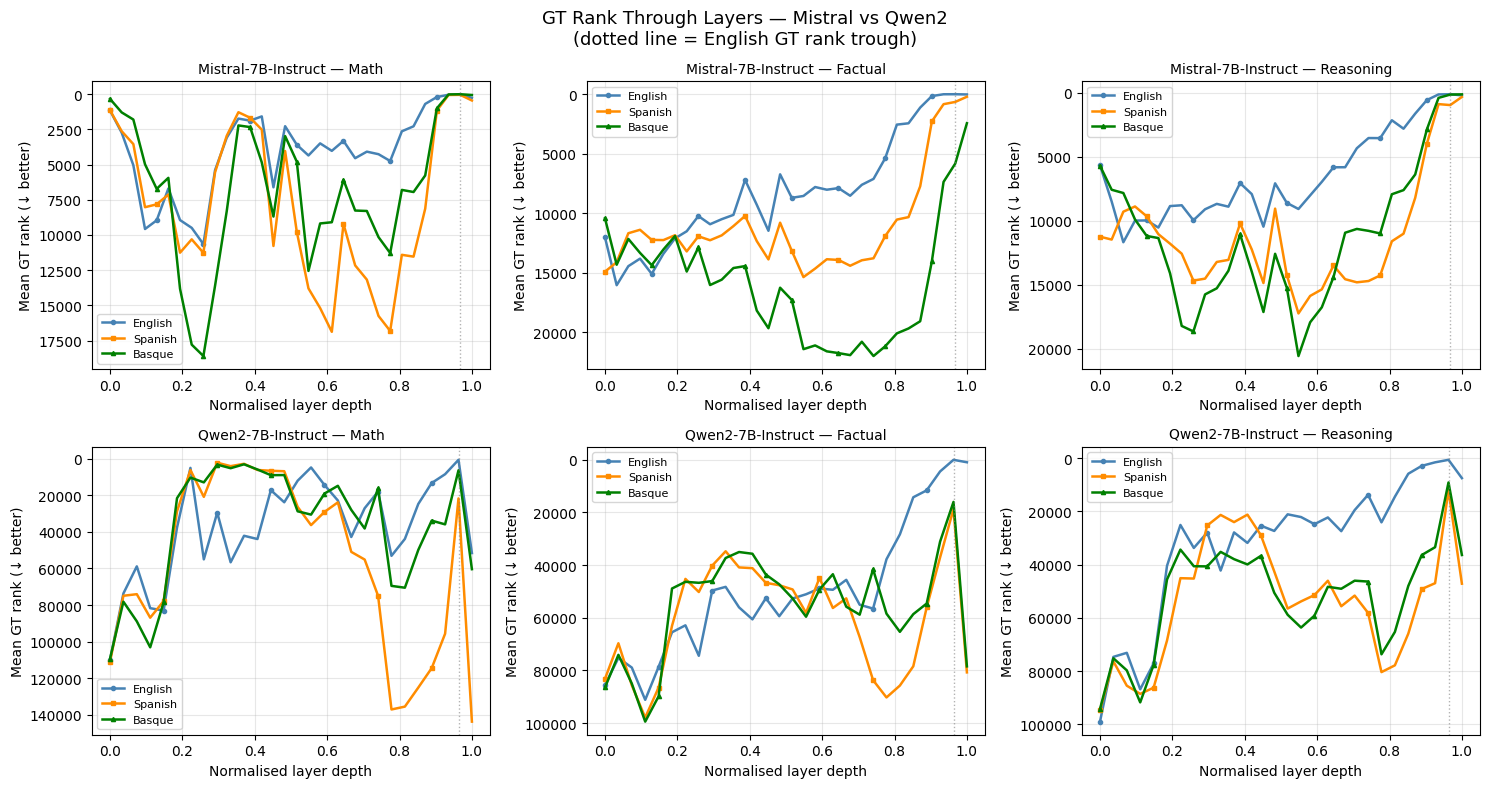

Saved figures/fig2_gt_rank_both_models.png


In [6]:
# ── Figure 2: GT rank by layer — both models, all languages ──────────────────
# Layer axis normalised to [0,1] so 32-layer Mistral and 28-layer Qwen overlay cleanly.
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for col, cat in enumerate(CATEGORIES):
    for row, (ll, m) in enumerate([(m_ll, MODEL_MISTRAL), (q_ll, MODEL_QWEN)]):
        ax = axes[row, col]
        x = np.linspace(0, 1, m["n_layers"])
        for lang in LANGS:
            rm = ll[lang][cat]["ranks"].mean(axis=0)
            ax.plot(x, rm, color=LANG_COLORS[lang], marker=LANG_MARKERS[lang],
                    linewidth=1.8, markersize=3, markevery=4, label=lang)
        # mark the trough (where GT rank is lowest = best)
        en_rm = ll["English"][cat]["ranks"].mean(axis=0)
        ax.axvline(x[en_rm.argmin()], color="gray", linestyle=":", linewidth=1, alpha=0.6)
        ax.invert_yaxis()
        ax.set_title(f"{m['label']} — {cat.capitalize()}", fontsize=10)
        ax.set_xlabel("Normalised layer depth")
        ax.set_ylabel("Mean GT rank (\u2193 better)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("GT Rank Through Layers — Mistral vs Qwen2\n"
             "(dotted line = English GT rank trough)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig2_gt_rank_both_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig2_gt_rank_both_models.png")

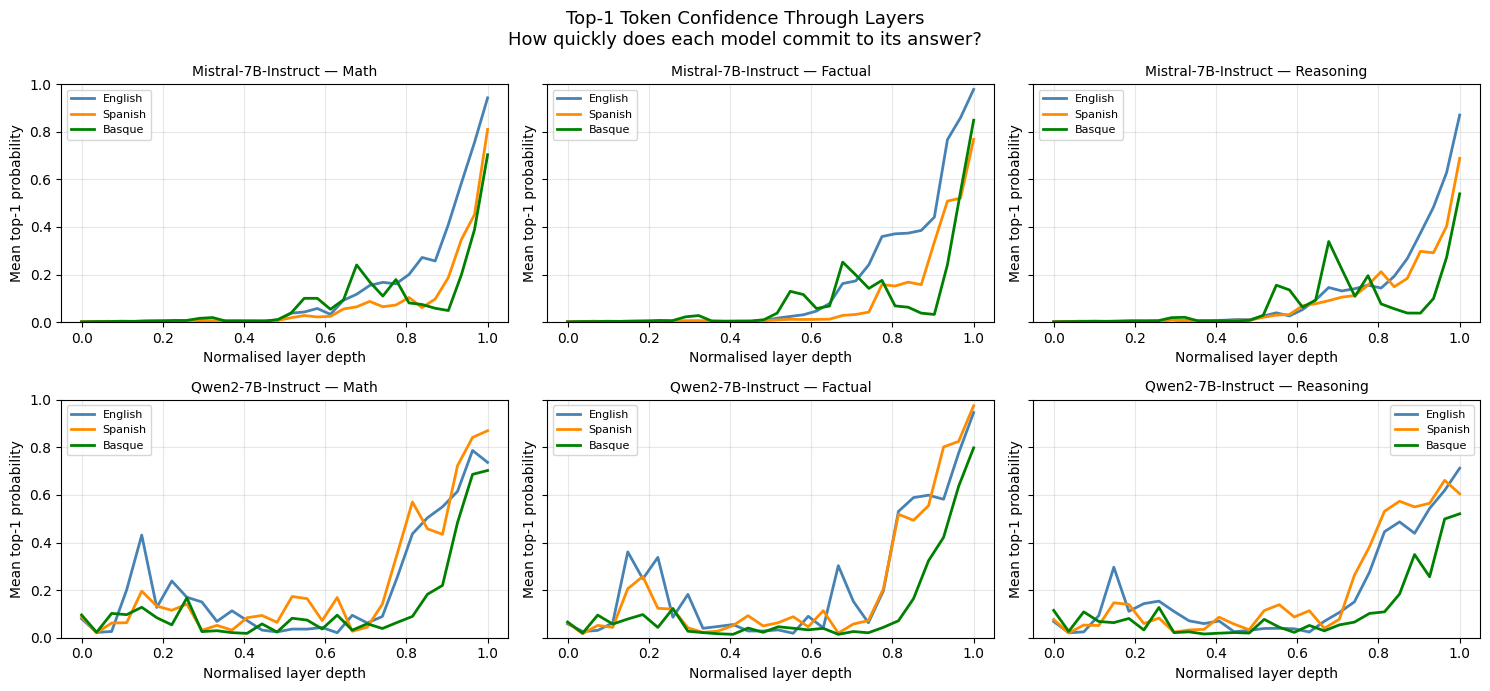

Saved figures/fig3_confidence_both_models.png


In [7]:
# ── Figure 3: Top-1 confidence — both models, all languages ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for col, cat in enumerate(CATEGORIES):
    for row, (ll, m) in enumerate([(m_ll, MODEL_MISTRAL), (q_ll, MODEL_QWEN)]):
        ax = axes[row, col]
        x = np.linspace(0, 1, m["n_layers"])
        for lang in LANGS:
            tm = ll[lang][cat]["top1"].mean(axis=0)
            ax.plot(x, tm, color=LANG_COLORS[lang], linewidth=2, label=lang)
        ax.set_title(f"{m['label']} — {cat.capitalize()}", fontsize=10)
        ax.set_xlabel("Normalised layer depth")
        ax.set_ylabel("Mean top-1 probability")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Top-1 Token Confidence Through Layers\n"
             "How quickly does each model commit to its answer?", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig3_confidence_both_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig3_confidence_both_models.png")

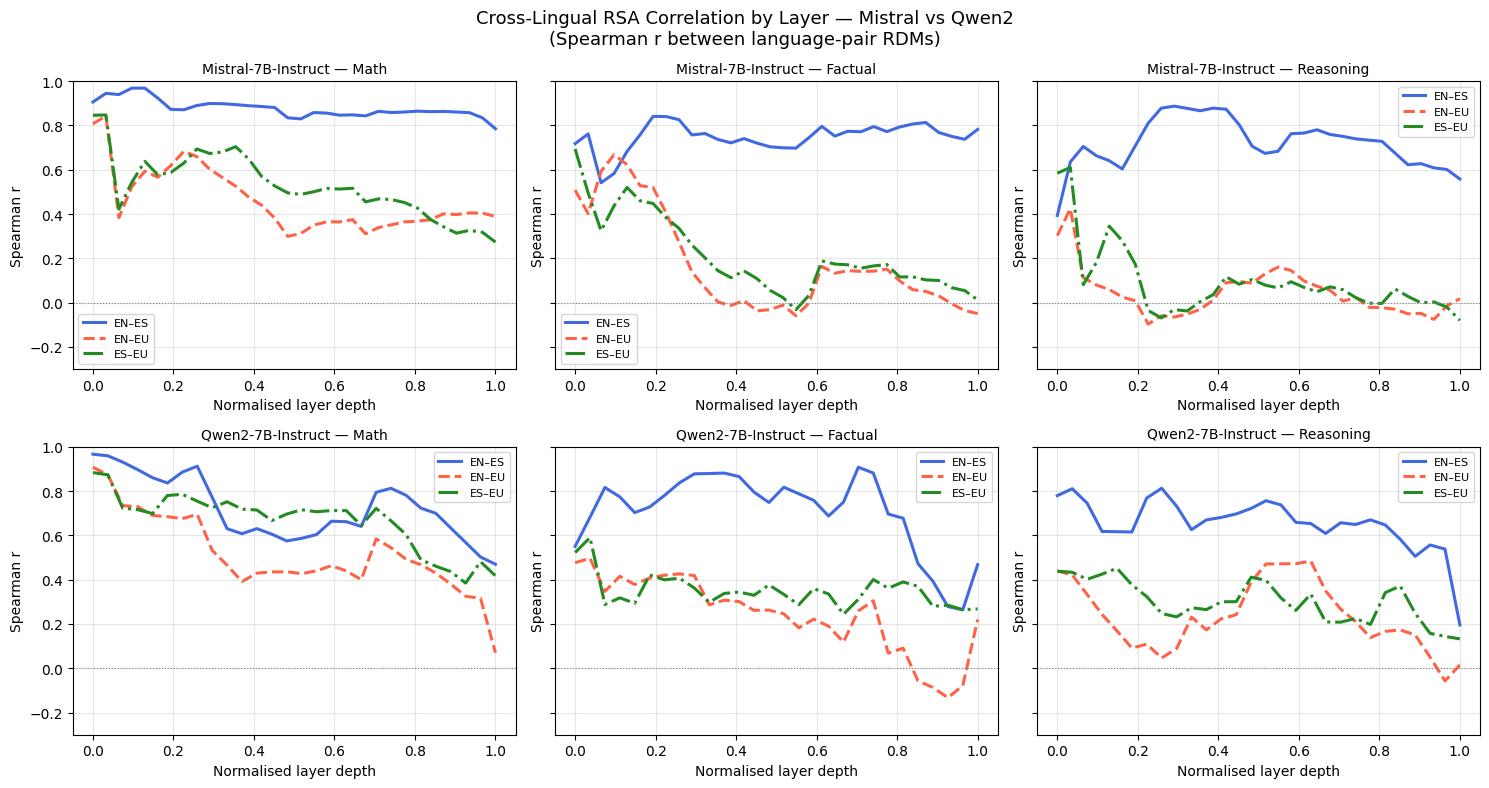

Saved figures/fig4_rsa_both_models.png


In [8]:
# ── Figure 4: RSA layer curves — both models ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for col, cat in enumerate(CATEGORIES):
    for row, (rsa, m) in enumerate([(m_rsa, MODEL_MISTRAL), (q_rsa, MODEL_QWEN)]):
        ax = axes[row, col]
        x = np.linspace(0, 1, m["n_layers"])
        for pair, (color, ls, label) in PAIR_STYLES.items():
            ax.plot(x, rsa[cat][pair], color=color, linestyle=ls, linewidth=2.2, label=label)
        ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
        ax.set_title(f"{m['label']} — {cat.capitalize()}", fontsize=10)
        ax.set_xlabel("Normalised layer depth")
        ax.set_ylabel("Spearman r")
        ax.set_ylim(-0.3, 1.0)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Lingual RSA Correlation by Layer — Mistral vs Qwen2\n"
             "(Spearman r between language-pair RDMs)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig4_rsa_both_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig4_rsa_both_models.png")

In [ ]:
# ── Figure 5: RSA final-layer heatmap ────────────────────────────────────────
pair_labels = ["EN\u2013ES", "EN\u2013EU", "ES\u2013EU"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (rsa, m) in zip(axes, [(m_rsa, MODEL_MISTRAL), (q_rsa, MODEL_QWEN)]):
    data = np.array([[rsa[cat][pair][-1] for pair in LANG_PAIRS] for cat in CATEGORIES])
    im = ax.imshow(data, vmin=-0.3, vmax=1.0, cmap="coolwarm", aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(pair_labels, fontsize=11)
    ax.set_yticks(range(3)); ax.set_yticklabels([c.capitalize() for c in CATEGORIES], fontsize=11)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if abs(data[i, j]) > 0.5 else "black")
    ax.set_title(m["label"], fontsize=12)
plt.suptitle("Cross-Lingual RSA at Final Layer\n"
             "Do the models share representational structure across languages?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig5_rsa_final_layer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig5_rsa_final_layer_heatmap.png")

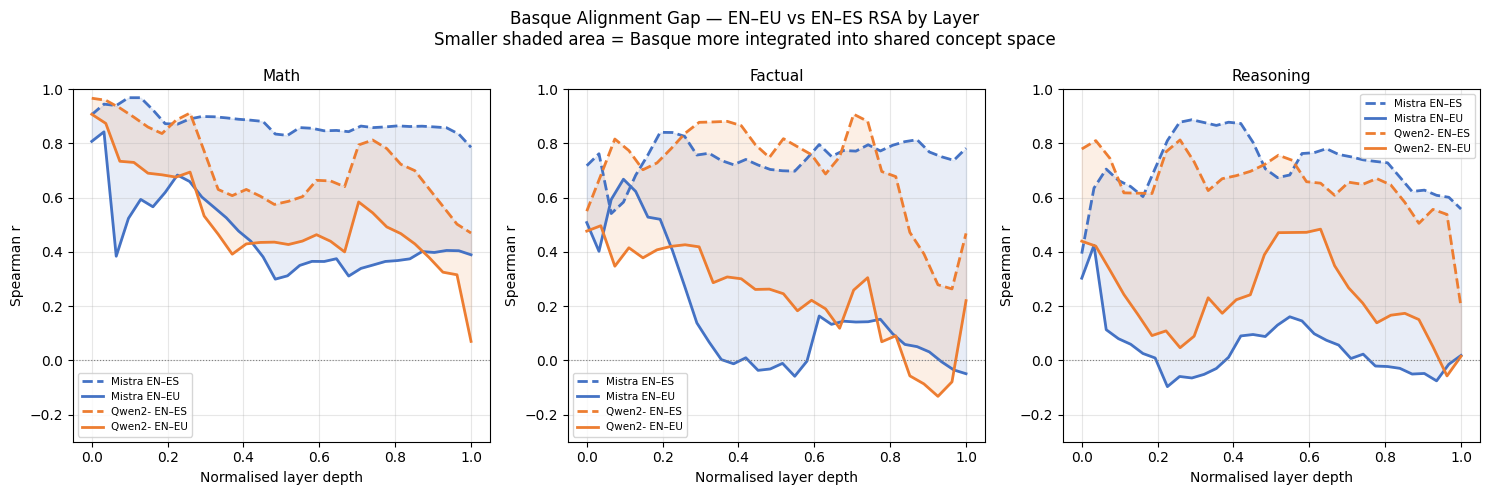

Saved figures/fig6_basque_gap.png


In [10]:
# ── Figure 6: Basque alignment gap — EN-EU vs EN-ES per model ────────────────
# Shaded region = the gap between how well each model aligns Basque vs Spanish
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cat in zip(axes, CATEGORIES):
    for rsa, m in [(m_rsa, MODEL_MISTRAL), (q_rsa, MODEL_QWEN)]:
        x = np.linspace(0, 1, m["n_layers"])
        es_curve = rsa[cat][("English", "Spanish")]
        eu_curve = rsa[cat][("English", "Basque")]
        ax.plot(x, es_curve, color=m["color"], linestyle="--", linewidth=2,
                label=f"{m['label'][:6]} EN\u2013ES")
        ax.plot(x, eu_curve, color=m["color"], linestyle="-",  linewidth=2,
                label=f"{m['label'][:6]} EN\u2013EU")
        ax.fill_between(x, eu_curve, es_curve, alpha=0.12, color=m["color"])
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Normalised layer depth")
    ax.set_ylabel("Spearman r")
    ax.set_ylim(-0.3, 1.0)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.suptitle("Basque Alignment Gap — EN\u2013EU vs EN\u2013ES RSA by Layer\n"
             "Smaller shaded area = Basque more integrated into shared concept space",
             fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig6_basque_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig6_basque_gap.png")

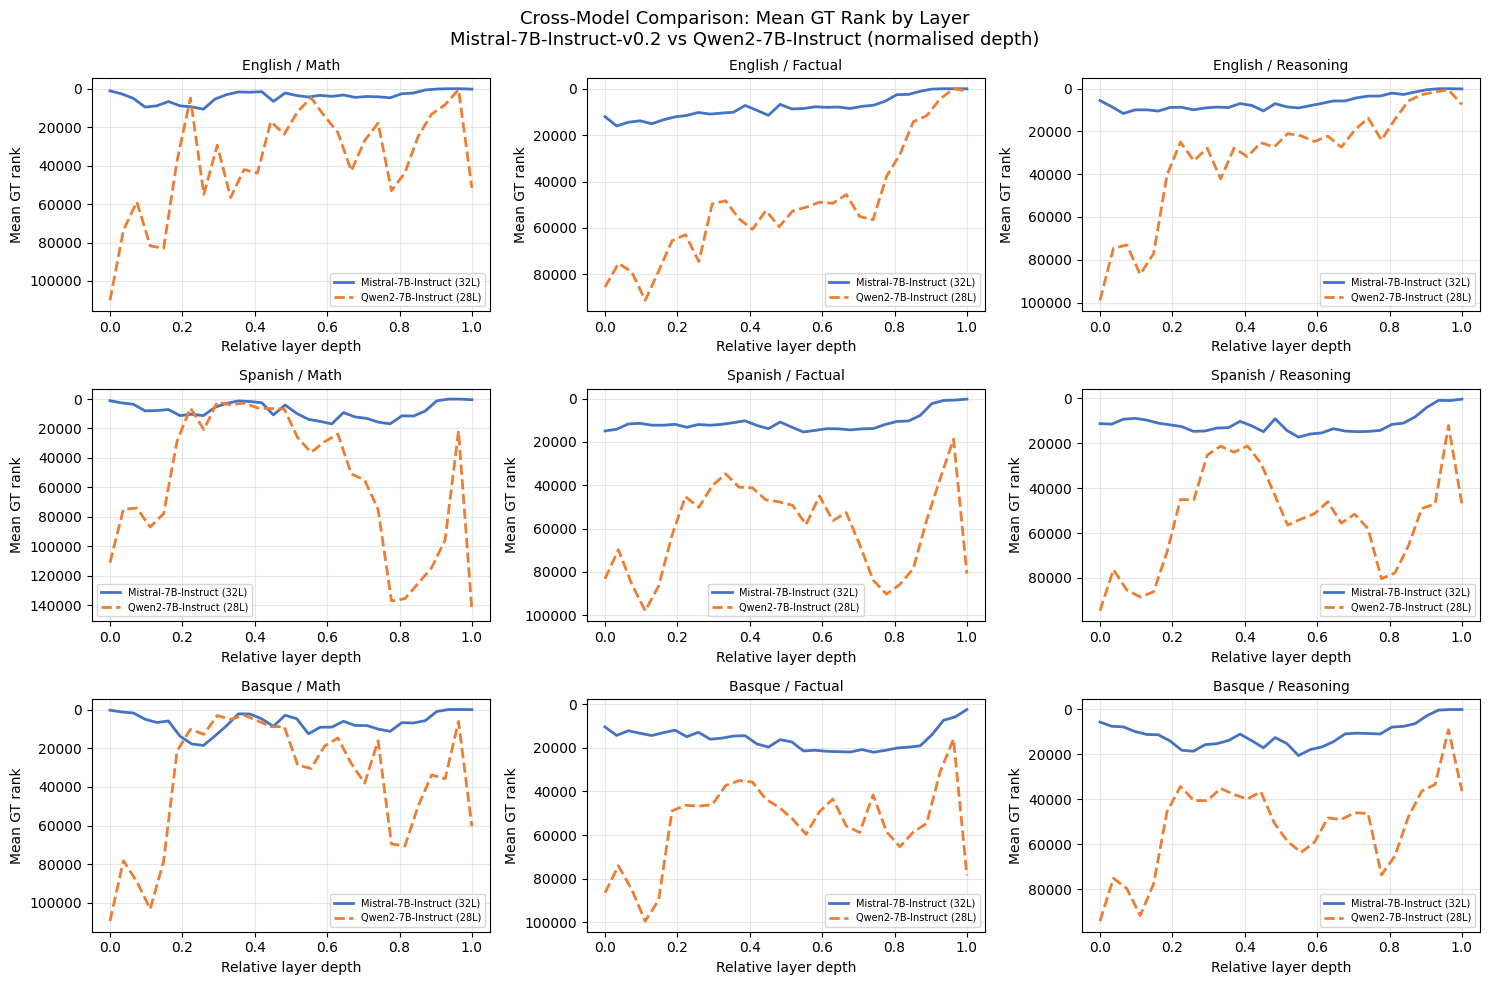

Saved figures/fig7_cross_model_gt_rank.png


In [11]:
# ── Figure 7: Cross-model GT rank comparison (3 langs × 3 cats) ──────────────
fig, axes = plt.subplots(len(LANGS), len(CATEGORIES), figsize=(15, 10), sharey=False)
for row, lang in enumerate(LANGS):
    for col, cat in enumerate(CATEGORIES):
        ax = axes[row, col]
        for ll, m in [(m_ll, MODEL_MISTRAL), (q_ll, MODEL_QWEN)]:
            x  = np.linspace(0, 1, m["n_layers"])
            rm = ll[lang][cat]["ranks"].mean(axis=0)
            ax.plot(x, rm, color=m["color"], linestyle=m["ls"], linewidth=2,
                    label=f"{m['label']} ({m['n_layers']}L)")
        ax.invert_yaxis()
        ax.set_title(f"{lang} / {cat.capitalize()}", fontsize=10)
        ax.set_xlabel("Relative layer depth")
        ax.set_ylabel("Mean GT rank")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Model Comparison: Mean GT Rank by Layer\n"
             "Mistral-7B-Instruct-v0.2 vs Qwen2-7B-Instruct (normalised depth)",
             fontsize=13)
plt.tight_layout()
plt.savefig("figures/fig7_cross_model_gt_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/fig7_cross_model_gt_rank.png")

In [12]:
# ── Summary statistics table ──────────────────────────────────────────────────
print("=" * 75)
print("ACCURACY")
print("=" * 75)
print(f"{'':12}" + "".join(f"{c:>14}" for c in CATEGORIES))
for lang in LANGS:
    row = f"{lang:<12}"
    for cat in CATEGORIES:
        row += f"  M={m_acc[lang][cat]:4.0f}% Q={q_acc[lang][cat]:4.0f}%"
    print(row)

print()
print("=" * 75)
print("RSA AT FINAL LAYER (Spearman r)")
print("=" * 75)
print(f"{'Category':<12} {'Pair':<8}  {'Mistral':>10}  {'Qwen2':>10}  {'\u0394':>8}")
print("-" * 55)
for cat in CATEGORIES:
    for pair, (_, _, label) in PAIR_STYLES.items():
        mr = m_rsa[cat][pair][-1]
        qr = q_rsa[cat][pair][-1]
        print(f"{cat:<12} {label:<8}  {mr:>10.3f}  {qr:>10.3f}  {qr-mr:>+8.3f}")

print()
print("=" * 75)
print("GT RANK AT FINAL LAYER (lower = better)")
print("=" * 75)
print(f"{'Category':<12} {'Lang':<10}  {'Mistral':>10}  {'Qwen2':>10}")
print("-" * 48)
for cat in CATEGORIES:
    for lang in LANGS:
        mr = m_ll[lang][cat]["ranks"][:, -1].mean()
        qr = q_ll[lang][cat]["ranks"][:, -1].mean()
        print(f"{cat:<12} {lang:<10}  {mr:>10.0f}  {qr:>10.0f}")

ACCURACY
                      math       factual     reasoning
English       M=  45% Q=  55%  M= 100% Q= 100%  M=  60% Q=  60%
Spanish       M=  50% Q=  70%  M= 100% Q=  95%  M=  35% Q=  65%
Basque        M=  20% Q=  65%  M=   0% Q=  30%  M=   5% Q=  15%

RSA AT FINAL LAYER (Spearman r)
Category     Pair         Mistral       Qwen2         Δ
-------------------------------------------------------
math         EN–ES          0.785       0.470    -0.316
math         EN–EU          0.389       0.070    -0.319
math         ES–EU          0.273       0.417    +0.144
factual      EN–ES          0.782       0.468    -0.314
factual      EN–EU         -0.049       0.220    +0.269
factual      ES–EU          0.013       0.268    +0.255
reasoning    EN–ES          0.558       0.196    -0.362
reasoning    EN–EU          0.018       0.015    -0.003
reasoning    ES–EU         -0.080       0.133    +0.212

GT RANK AT FINAL LAYER (lower = better)
Category     Lang           Mistral       Qwen2
------